# TFM - Predicción de morosidad y scoring crediticio

## 1. Inicialización del entorno y carga de datos

In [1]:
# Importación de librerías necesarias para el análisis y el modelado
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Configuración inicial del entorno y definición de una semilla reproducible
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Carga del dataset y visualización inicial de sus dimensiones y primeros registros
ruta = "../data/data.csv"
df = pd.read_csv(ruta)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (8399, 14)


,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.000,5,3500.000,NaN,0.000,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.000,12,900.000,1824.670,1933.750,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.000,2,2400.000,2797.380,188.290,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.000,12,2700.000,NaN,0.000,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.000,2000.000,11010.650,189,Lima,0,TECNICA


## 2. Exploración

In [4]:
# Exploración general de la estructura y estadísticas descriptivas del dataset
print("Resumen de información del dataset:\n")
df.info()

print("\nResumen de estadísticas descriptivas del dataset:\n")
df.describe()

Resumen de información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   object 
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   object 
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 918.8+ KB

Resumen de estadísticas descriptivas del dataset:



,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000,8399.000,8399.000,8399.000,6569.000,8399.000,8399.000,7272.000,7938.000,8399.000,8399.000
mean,0.704,4.463,36.399,5555.889,32.402,10.593,4350.407,11987.241,6110.724,196.620,0.564
std,0.456,14.271,9.826,2153.244,32.866,3.375,5367.059,21322.802,11177.990,19.544,0.906
min,0.000,0.000,20.000,2956.000,0.000,0.000,123.700,0.000,0.000,134.000,0.000
25%,0.000,0.000,29.000,4174.000,7.000,12.000,1366.670,1169.372,478.320,182.000,0.000
50%,1.000,0.000,34.000,4904.000,20.000,12.000,2400.000,4030.120,2258.755,197.000,0.000
75%,1.000,2.000,42.000,6182.000,51.000,12.000,4900.000,12086.627,5755.150,212.000,1.000
max,1.000,245.000,85.000,20700.000,130.000,12.000,30000.000,121543.400,57094.380,266.000,4.000


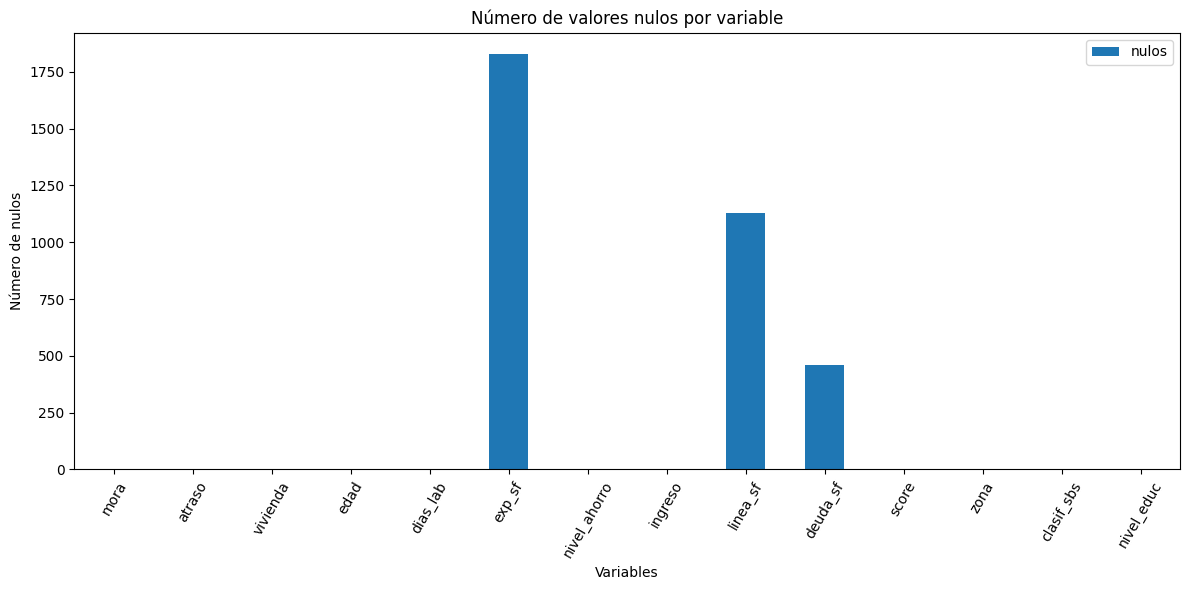

Resumen de variables con valores nulos:

exp_sf      1830
linea_sf    1127
deuda_sf     461
dtype: int64


In [5]:
# Análisis gráfico y resumen de los valores nulos por variable
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "nulos": missing_values
})

ax = missing_df.plot(kind="bar", figsize=(12,6))

ax.set_title("Número de valores nulos por variable")
ax.set_xlabel("Variables")
ax.set_ylabel("Número de nulos")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print("Resumen de variables con valores nulos:\n")
print(missing_values[missing_values > 0].sort_values(ascending=False))

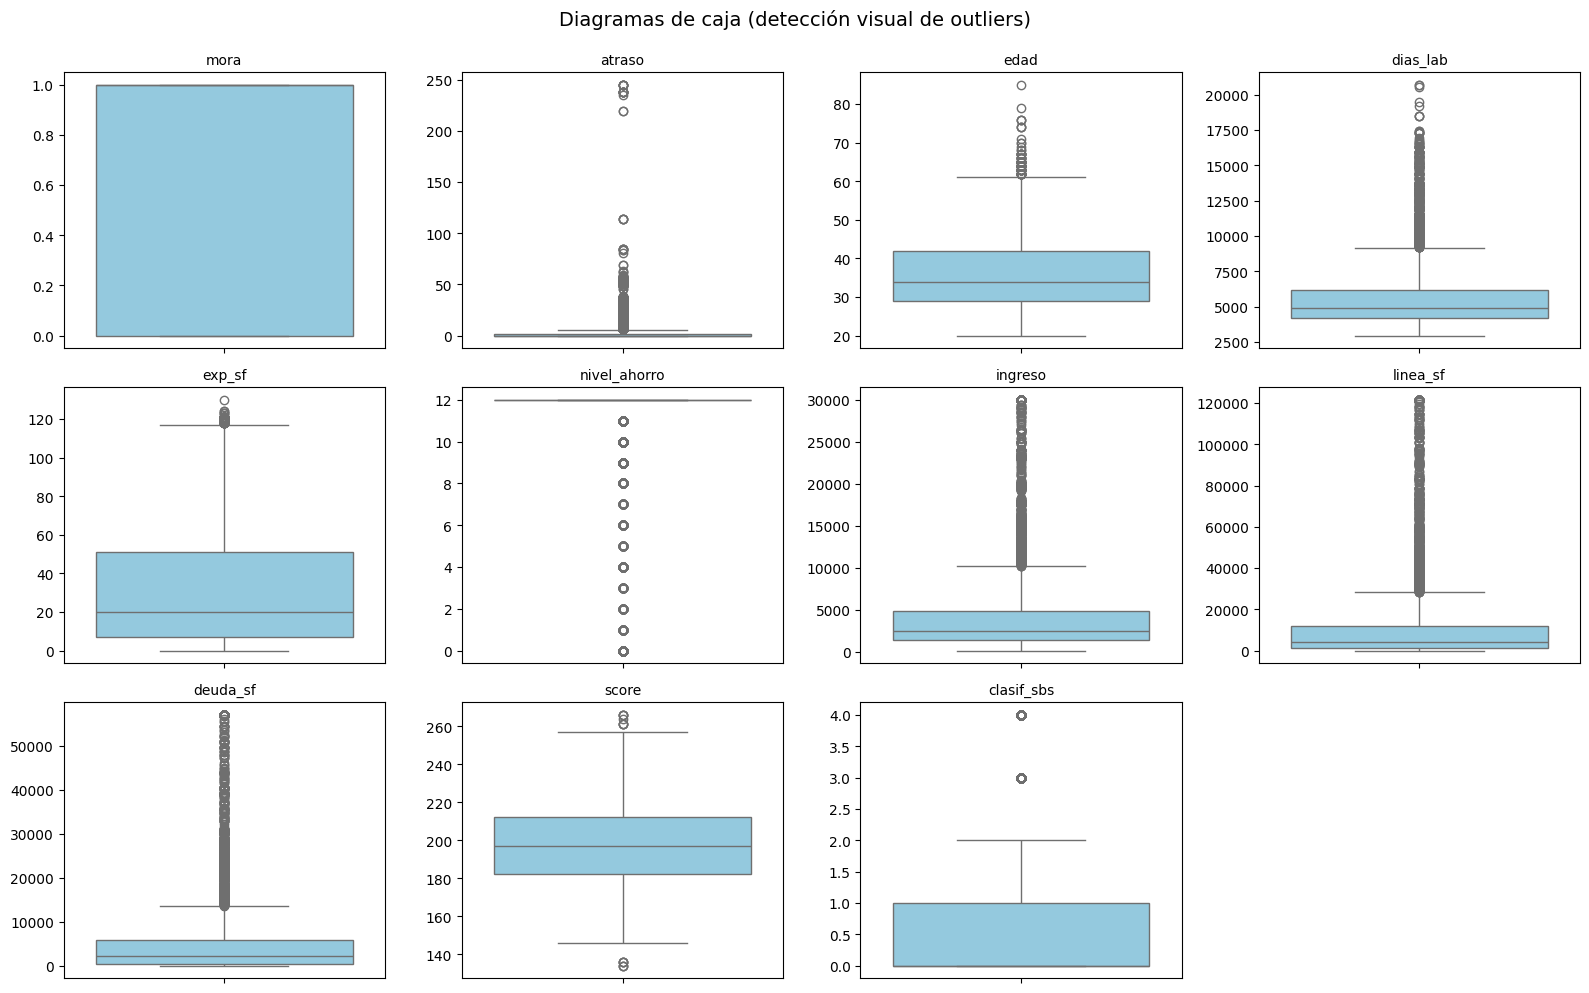

In [6]:
# Detección visual de posibles valores atípicos en las variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel("")

plt.tight_layout()
plt.suptitle("Diagramas de caja (detección visual de outliers)", y=1.03, fontsize=14)

plt.show()

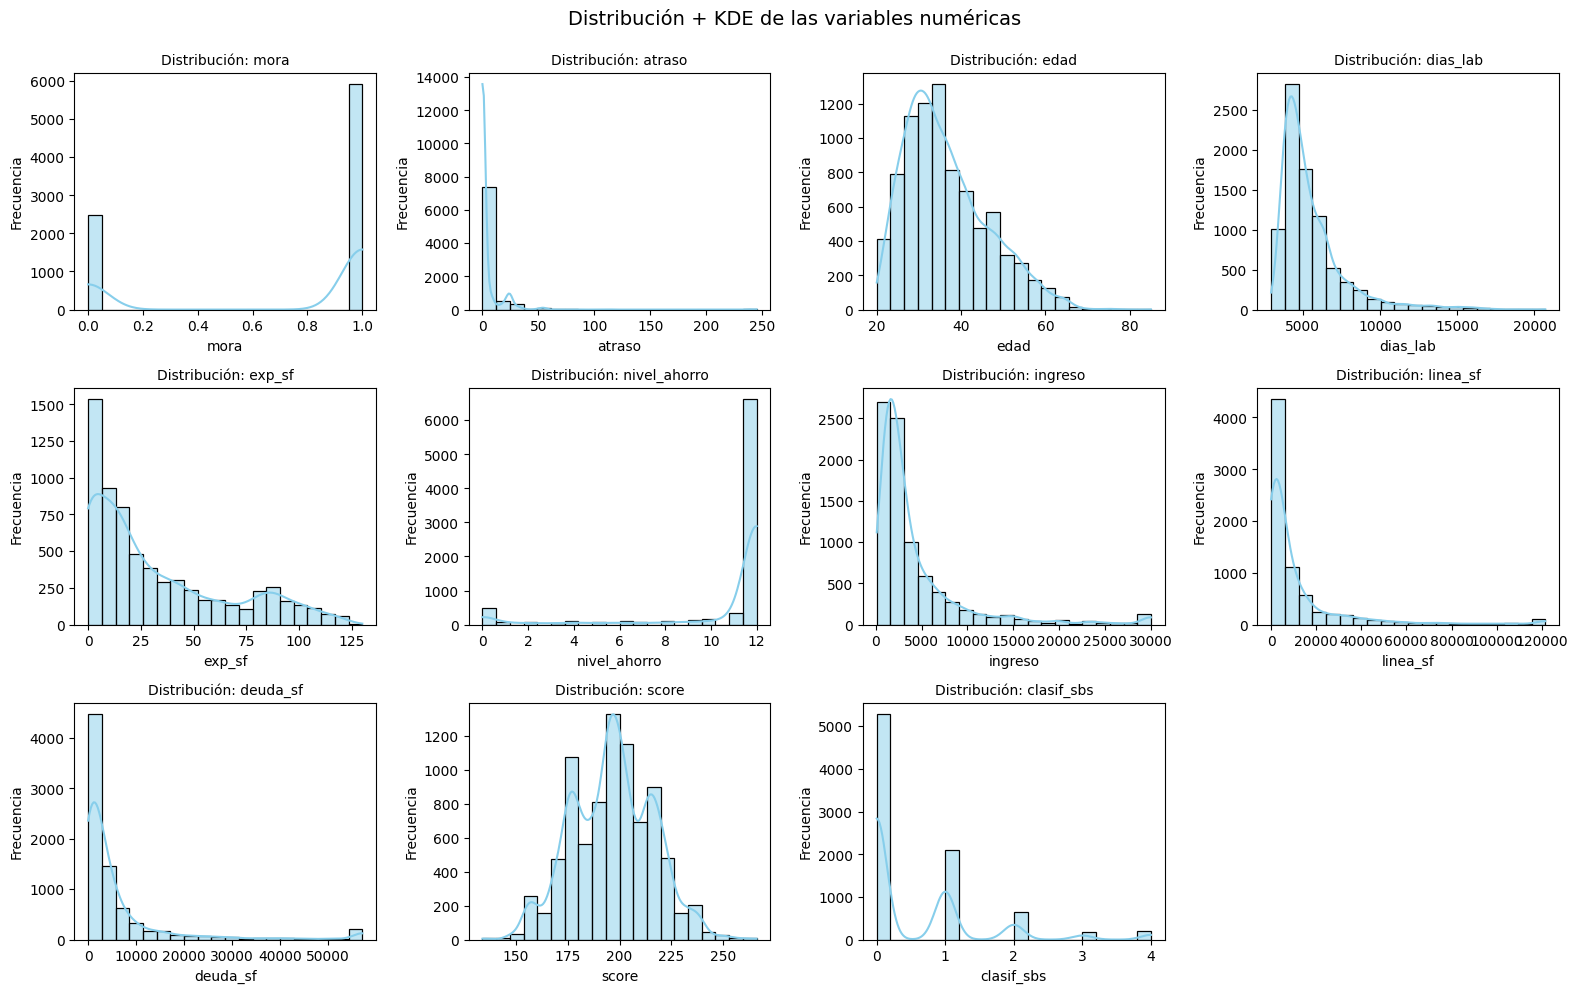

In [7]:
# Visualización de la distribución de las variables numéricas
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], bins=20, kde=True, edgecolor='black', color='skyblue')
    plt.title(f"Distribución: {col}", fontsize=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.suptitle("Distribución + KDE de las variables numéricas", y=1.03, fontsize=14)

plt.show()

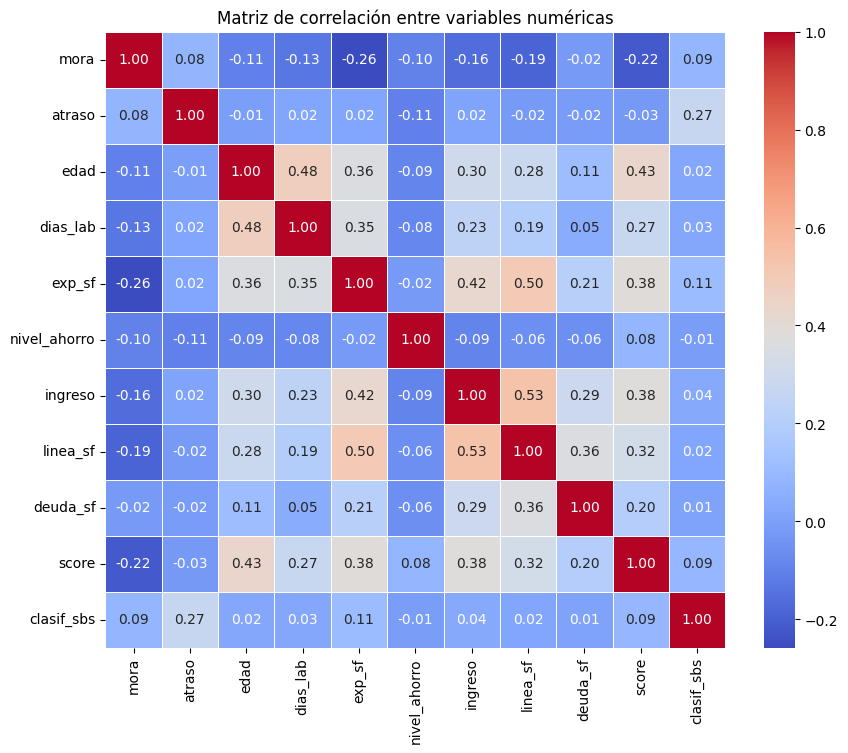

In [8]:
# Cálculo y representación de la matriz de correlación entre variables numéricas
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

## 3. Preprocesamiento

In [9]:
# Imputación de valores nulos mediante la mediana en las variables seleccionadas
df["exp_sf"].fillna(df["exp_sf"].median(), inplace=True)
df["linea_sf"].fillna(df["linea_sf"].median(), inplace=True)
df["deuda_sf"].fillna(df["deuda_sf"].median(), inplace=True)

In [10]:
# Comprobación de valores nulos tras el proceso de imputación
print("Valores nulos después de la imputación:\n")
print(df.isnull().sum())

Valores nulos después de la imputación:

mora            0
atraso          0
vivienda        0
edad            0
dias_lab        0
exp_sf          0
nivel_ahorro    0
ingreso         0
linea_sf        0
deuda_sf        0
score           0
zona            0
clasif_sbs      0
nivel_educ      0
dtype: int64


In [11]:
# Aplicación de transformaciones logarítmicas para reducir la asimetría de algunas variables
df["log_ingreso"] = np.log1p(df["ingreso"])
df["log_linea_sf"] = np.log1p(df["linea_sf"])
df["log_deuda_sf"] = np.log1p(df["deuda_sf"])
df["log_atraso"] = np.log1p(df["atraso"])
df["log_exp_sf"] = np.log1p(df["exp_sf"])

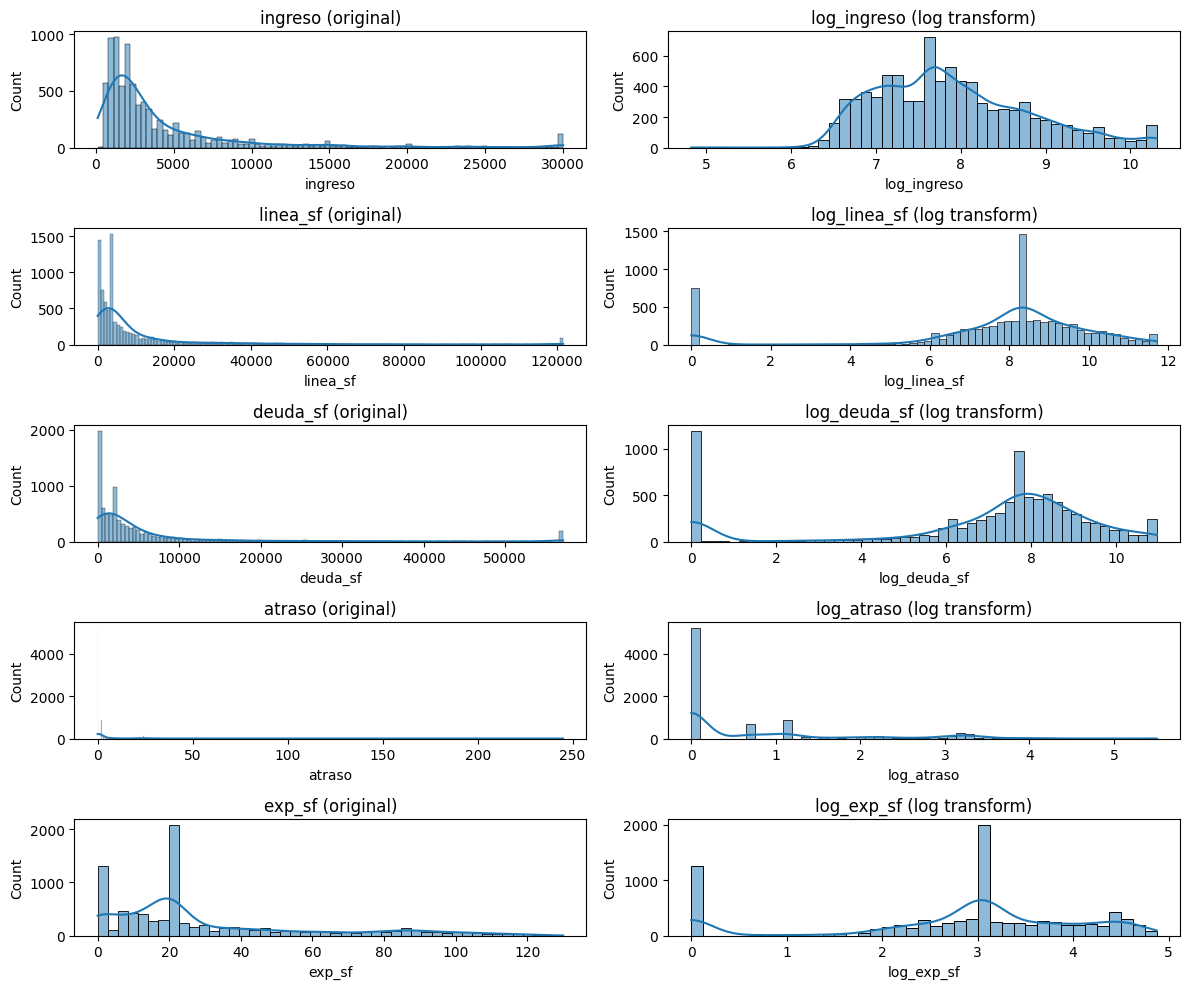

In [12]:
# Comparación gráfica entre las variables originales y sus versiones transformadas
log_pairs = [
    ("ingreso", "log_ingreso"),
    ("linea_sf", "log_linea_sf"),
    ("deuda_sf", "log_deuda_sf"),
    ("atraso", "log_atraso"),
    ("exp_sf", "log_exp_sf")
]

plt.figure(figsize=(12,10))

for i, (orig, log) in enumerate(log_pairs, 1):

    plt.subplot(len(log_pairs), 2, 2*i-1)
    sns.histplot(df[orig], kde=True)
    plt.title(f"{orig} (original)")

    plt.subplot(len(log_pairs), 2, 2*i)
    sns.histplot(df[log], kde=True)
    plt.title(f"{log} (log transform)")

plt.tight_layout()
plt.show()

In [13]:
# Eliminación de las variables originales sustituidas por sus transformaciones logarítmicas
cols_replace = ['ingreso','linea_sf','deuda_sf','atraso','exp_sf']

for col in cols_replace:
    df.drop(columns=col, inplace=True)

In [14]:
# Revisión de la estructura del dataset tras las transformaciones aplicadas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   vivienda      8399 non-null   object 
 2   edad          8399 non-null   int64  
 3   dias_lab      8399 non-null   int64  
 4   nivel_ahorro  8399 non-null   int64  
 5   score         8399 non-null   int64  
 6   zona          8399 non-null   object 
 7   clasif_sbs    8399 non-null   int64  
 8   nivel_educ    8399 non-null   object 
 9   log_ingreso   8399 non-null   float64
 10  log_linea_sf  8399 non-null   float64
 11  log_deuda_sf  8399 non-null   float64
 12  log_atraso    8399 non-null   float64
 13  log_exp_sf    8399 non-null   float64
dtypes: float64(5), int64(6), object(3)
memory usage: 918.8+ KB


In [15]:
# Codificación de variables categóricas para su uso en el modelado
df = df.copy()

nivel_educ_map = {
    "SIN EDUCACION": 0,
    "SECUNDARIA": 1,
    "TECNICA": 2,
    "UNIVERSITARIA": 3
}

df["nivel_educ"] = df["nivel_educ"].map(nivel_educ_map)

print("Codificación aplicada a 'nivel_educ':")
print(nivel_educ_map)

df = pd.get_dummies(
    df,
    columns=["vivienda", "zona"],
    drop_first=True
)

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nDimensión del dataset después de la codificación:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nVariables categóricas restantes:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nPrimeras filas del dataset:")
print(df.head())

Codificación aplicada a 'nivel_educ':
{'SIN EDUCACION': 0, 'SECUNDARIA': 1, 'TECNICA': 2, 'UNIVERSITARIA': 3}

Dimensión del dataset después de la codificación:
(8399, 38)

Tipos de datos:
int64      33
float64     5
Name: count, dtype: int64

Variables categóricas restantes:
[]

Primeras filas del dataset:
   mora  edad  dias_lab  nivel_ahorro  score  clasif_sbs  nivel_educ  \
0     0    30      3748             5    214           4           3   
1     0    32      4598            12    175           1           2   
2     0    26      5148             2    187           0           3   
3     0    36      5179            12    187           0           2   
4     0    46      3960             1    189           0           2   

   log_ingreso  log_linea_sf  log_deuda_sf  log_atraso  log_exp_sf  \
0        8.161         8.302         0.000       5.464       4.543   
1        6.804         7.510         7.568       2.944       2.303   
2        7.784         7.937         5.243      

## 4. Preparación para modelado

In [16]:
# Separación entre variables predictoras y variable objetivo
X = df.drop("mora", axis=1)
y = df["mora"]

In [17]:
# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# Aplicación de distintos métodos de escalado sobre los datos de entrenamiento y prueba
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)

## 5. Modelado

In [19]:
# Definición de la estrategia de validación cruzada y de la métrica principal de evaluación
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = "f1"

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nDistribución de clases en y_train:")
print(y_train.value_counts(normalize=True))

X_train shape: (6719, 37)
X_test shape: (1680, 37)
y_train shape: (6719,)
y_test shape: (1680,)

Distribución de clases en y_train:
mora
1   0.704
0   0.296
Name: proportion, dtype: float64


In [20]:
# Definición de los modelos de clasificación y de sus espacios de búsqueda de hiperparámetros
model_spaces = {
    "LogisticRegression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=42))
        ]),
        "params": {
            "scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
            "model__C": np.logspace(-2, 2, 8),
            "model__solver": ["liblinear", "lbfgs"]
        }
    },

    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
            "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },

    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42))
        ]),
        "params": {
            "scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale"]
        }
    },

    "RandomForest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300, 400],
            "model__max_depth": [None, 5, 10, 15, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        }
    },

    "AdaBoost": {
        "pipeline": Pipeline([
            ("model", AdaBoostClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42
            ))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 150, 200],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
            "model__estimator__max_depth": [1, 2, 3, 4]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    }
}

print("Modelos configurados:", list(model_spaces.keys()))

Modelos configurados: ['LogisticRegression', 'KNN', 'SVM', 'RandomForest', 'AdaBoost', 'XGBoost']


In [21]:
# Función para evaluar cada modelo de clasificación sobre el conjunto de prueba
def evaluar_modelo(nombre_modelo, search, X_test, y_test):

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:,1]
    else:
        y_proba = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Mejores parámetros": search.best_params_,
        "Best_Model": best_model
    }

In [22]:
# Entrenamiento y ajuste de los distintos modelos de clasificación mediante búsqueda aleatoria
results = []

for name, spec in model_spaces.items():

    print(f"\nEntrenando modelo: {name}")

    search = RandomizedSearchCV(
        estimator=spec["pipeline"],
        param_distributions=spec["params"],
        n_iter=10,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    search.fit(X_train, y_train)

    result = evaluar_modelo(name, search, X_test, y_test)

    results.append(result)


Entrenando modelo: LogisticRegression


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_linea


Entrenando modelo: KNN

Entrenando modelo: SVM

Entrenando modelo: RandomForest

Entrenando modelo: AdaBoost

Entrenando modelo: XGBoost


In [23]:
# Construcción y ordenación del resumen final de resultados de clasificación
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

display(results_df.drop(columns=["Best_Model"]))

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Mejores parámetros
0,RandomForest,0.884,0.870,0.981,0.923,0.937,"{'model__n_estimators': 300, 'model__min_sampl..."
1,KNN,0.857,0.861,0.950,0.903,0.900,"{'scaler': RobustScaler(), 'model__weights': '..."
2,XGBoost,0.817,0.821,0.947,0.879,0.864,"{'model__subsample': 1.0, 'model__n_estimators..."
3,SVM,0.757,0.777,0.918,0.842,0.765,"{'scaler': StandardScaler(), 'model__kernel': ..."
4,AdaBoost,0.743,0.758,0.932,0.836,0.760,"{'model__n_estimators': 150, 'model__learning_..."
5,LogisticRegression,0.727,0.746,0.929,0.828,0.721,"{'scaler': MinMaxScaler(), 'model__solver': 'l..."


In [24]:
# Identificación y visualización del mejor modelo de clasificación obtenido
best_model_name = results_df.iloc[0]["Modelo"]
best_model = results_df.iloc[0]["Best_Model"]

print("Mejor modelo encontrado:")
print(best_model_name)
print("\nPipeline final:")
print(best_model)

Mejor modelo encontrado:
RandomForest

Pipeline final:
Pipeline(steps=[('model',
                 RandomForestClassifier(max_features='log2',
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])


In [25]:
# Ajuste específico de un modelo Random Forest para profundizar en su análisis
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [15, 20, 25, None],
    "model__min_samples_split": [2, 5, 8],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Mejores parámetros Random Forest:")
print(rf_grid.best_params_)

print("\nMétricas en test:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC_AUC:", roc_auc_score(y_test, y_proba_rf))

Mejores parámetros Random Forest:
{'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Métricas en test:
Accuracy: 0.8904761904761904
Precision: 0.8786959818043972
Recall: 0.9797125950972105
F1: 0.926458832933653
ROC_AUC: 0.9468493122726214


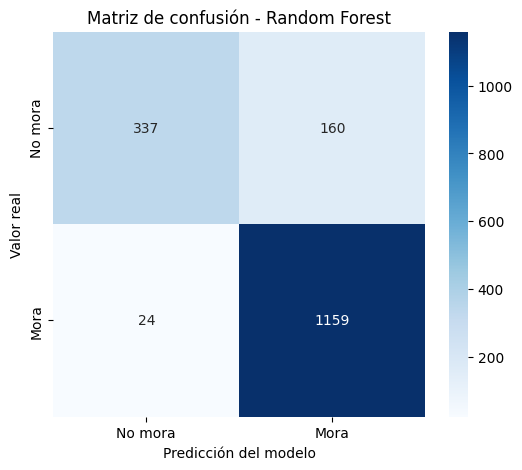

In [26]:
# Cálculo y representación de la matriz de confusión del modelo Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No mora", "Mora"],
    yticklabels=["No mora", "Mora"]
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest")

plt.show()

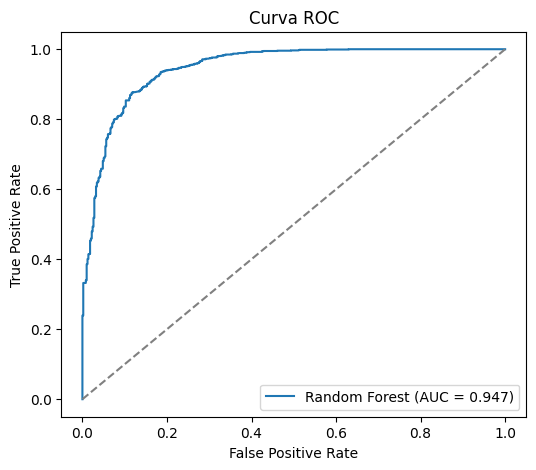

In [27]:
# Representación de la curva ROC y cálculo del área bajo la curva del modelo Random Forest
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend(loc="lower right")

plt.show()

In [28]:
# Cálculo de la importancia de las variables en el modelo Random Forest
importances = best_rf.named_steps["model"].feature_importances_

features = X_train.columns

feat_importance = pd.DataFrame({
    "Variable": features,
    "Importancia": importances
})

feat_importance = feat_importance.sort_values(
    by="Importancia",
    ascending=False
)

feat_importance

,Variable,Importancia
6,log_ingreso,0.121
7,log_linea_sf,0.114
1,dias_lab,0.114
10,log_exp_sf,0.112
3,score,0.106
8,log_deuda_sf,0.104
0,edad,0.092
9,log_atraso,0.049
4,clasif_sbs,0.033
2,nivel_ahorro,0.033


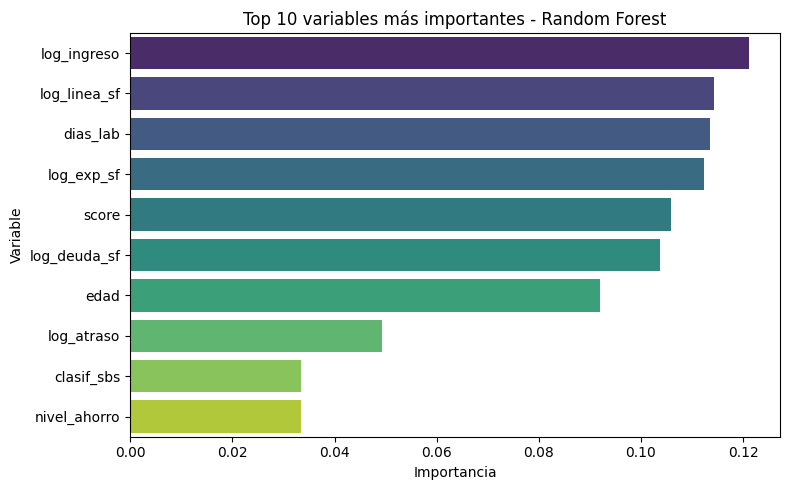

In [29]:
# Visualización de las variables más relevantes según su importancia en Random Forest
top_features = feat_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="Importancia",
    y="Variable",
    palette="viridis"
)

plt.title("Top 10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

## 6. Análisis exploratorio adicional: predicción del score crediticio

In [30]:
# Importación de librerías necesarias para el análisis exploratorio de regresión
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [31]:
# Definición de variables predictoras y objetivo para la predicción del score crediticio
y_reg = df["score"]

X_reg = df.drop(columns=["score", "mora"], errors="ignore")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg:", X_test_reg.shape)

X_train_reg: (6719, 36)
X_test_reg: (1680, 36)


In [32]:
# Definición de la validación cruzada y de los modelos de regresión a comparar
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

regression_spaces = {
    "LinearRegression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {}
    },

    "RandomForestRegressor": {
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "XGBRegressor": {
        "pipeline": Pipeline([
            ("model", XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [33]:
# Función para evaluar el rendimiento de los modelos de regresión
def evaluar_modelo_regresion(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Modelo": nombre_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [34]:
# Entrenamiento y evaluación de los distintos modelos de regresión planteados
results_reg = []

for name, spec in regression_spaces.items():
    print(f"\nEntrenando modelo de regresión: {name}")

    if name == "LinearRegression":
        model = spec["pipeline"]
        model.fit(X_train_reg, y_train_reg)
        result = evaluar_modelo_regresion(name, model, X_test_reg, y_test_reg)
        results_reg.append(result)

    else:
        search = RandomizedSearchCV(
            estimator=spec["pipeline"],
            param_distributions=spec["params"],
            n_iter=8,
            cv=cv_reg,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            random_state=42,
            refit=True
        )

        search.fit(X_train_reg, y_train_reg)
        best_model = search.best_estimator_

        result = evaluar_modelo_regresion(name, best_model, X_test_reg, y_test_reg)
        result["Mejores parámetros"] = search.best_params_

        results_reg.append(result)


Entrenando modelo de regresión: LinearRegression

Entrenando modelo de regresión: RandomForestRegressor

Entrenando modelo de regresión: XGBRegressor


In [35]:
# Construcción y ordenación del resumen final de resultados de regresión
results_reg_df = pd.DataFrame(results_reg)
results_reg_df = results_reg_df.sort_values(by="MAE", ascending=True).reset_index(drop=True)

display(results_reg_df)

,Modelo,MAE,RMSE,R2,Mejores parámetros
0,RandomForestRegressor,5.474,8.262,0.820,"{'model__n_estimators': 100, 'model__min_sampl..."
1,XGBRegressor,7.506,10.040,0.734,"{'model__subsample': 1.0, 'model__n_estimators..."
2,LinearRegression,10.203,13.112,0.547,NaN


In [36]:
# Identificación del modelo de regresión con mejor comportamiento en esta fase exploratoria
best_reg_model = results_reg_df.iloc[0]["Modelo"]

print(f"El modelo de regresión con mejor comportamiento exploratorio ha sido: {best_reg_model}")

El modelo de regresión con mejor comportamiento exploratorio ha sido: RandomForestRegressor
